# CBIM Problem Canvas

### Situation (S)
A regional retail chain operates 12 stores across Andhra Pradesh and sells products across five categories: Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care. The Category Manager is preparing for a quarterly supplier review and needs a clear understanding of category and product performance.

### Complication (C)
The Category Manager needs to decide which categories deserve continued or increased shelf space and promotional investment, but she needs evidence from the six months of transaction data to identify growing, declining, and consistently performing categories.

### Question (Q)
Which product categories are growing, declining, or consistently performing over the six-month period, and which categories should the Category Manager prioritise or deprioritise during the supplier review?

### SSOT
MUC01_Retail_Sales_Dataset.csv, containing six months of retail transaction data from January to June 2026.

### Success Definition
The analysis will clearly identify the growing, declining, and most consistent categories using revenue trends and business interpretation, enabling the Category Manager to make informed supplier and investment decisions.

### Primary Stakeholder
The Category Manager, who needs a data-backed view of category performance to make decisions about shelf space, promotional investment, and supplier priorities.

In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("MUC01_Retail_Sales_Dataset 1 (2).csv")

# Display the first five rows so we can confirm that the data loaded correctly.
display(df.head())

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
# Check shape
print("Dataset Shape:", df.shape)

Dataset Shape: (107836, 10)


In [4]:
# Display first 5 rows
display(df.head())

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [5]:
# Check data types
print(df.dtypes)

transaction_id        str
date                  str
store_id              str
store_city            str
category              str
product_name          str
units_sold          int64
unit_price        float64
revenue           float64
discount_pct        int64
dtype: object


In [6]:
# Check missing values
print(df.isnull().sum())

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


In [7]:
# Statistical summary
display(df.describe())

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


In [8]:
# Unique products
print("Number of unique products:", df['product_name'].nunique())

Number of unique products: 25


In [9]:
# Unique categories
print("Number of unique categories:", df['category'].nunique())

Number of unique categories: 5


In [10]:
# Category names
print("Categories:", df['category'].unique())

Categories: <StringArray>
['Electronics', 'Apparel', 'Grocery', 'Home & Kitchen', 'Personal Care']
Length: 5, dtype: str


Step 5.1 — Data Inspection

The dataset contains 107,836 retail transactions across 10 columns, covering January to June 2026. There are 25 unique products across 5 product categories, with no missing values in any column.

The average transaction contains approximately 2.6 units, suggesting that customers generally purchase multiple units per transaction and that bundle or cross-selling opportunities may exist. The average transaction revenue is approximately ₹4,264, while the maximum transaction revenue is approximately ₹3.55 lakh, indicating substantial variation in transaction value, potentially due to high-priced products.

In [11]:
# Convert the date column to datetime format
df['date'] = pd.to_datetime(df['date'])
df.dtypes

transaction_id               str
date              datetime64[us]
store_id                     str
store_city                   str
category                     str
product_name                 str
units_sold                 int64
unit_price               float64
revenue                  float64
discount_pct               int64
dtype: object

In [12]:
# Extract the year and month from each transaction date
df['month'] = df['date'].dt.to_period('M')

In [13]:
# Preview the date and month columns
df[['date', 'month']].head()

,date,month
0,2026-01-01,2026-01
1,2026-01-01,2026-01
2,2026-01-01,2026-01
3,2026-01-01,2026-01
4,2026-01-01,2026-01


In [14]:
# Calculate total revenue for each category by month
monthly_category_revenue = (
    df.groupby(['month', 'category'])['revenue']
      .sum()
      .reset_index()
)

In [15]:
# Preview the first monthly category revenue results
monthly_category_revenue.head(10)

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


In [16]:
# Recalculate monthly revenue by category
monthly_category_revenue = (
    df.groupby(['month', 'category'])['revenue']
      .sum()
      .reset_index()
)

In [17]:
# Display all monthly category revenue results
monthly_category_revenue

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


In [18]:
# Convert month periods to strings for plotting
monthly_category_revenue['month'] = monthly_category_revenue['month'].astype(str)

In [19]:
# Check the data types after preparing the monthly revenue table
monthly_category_revenue.dtypes

month           str
category        str
revenue     float64
dtype: object

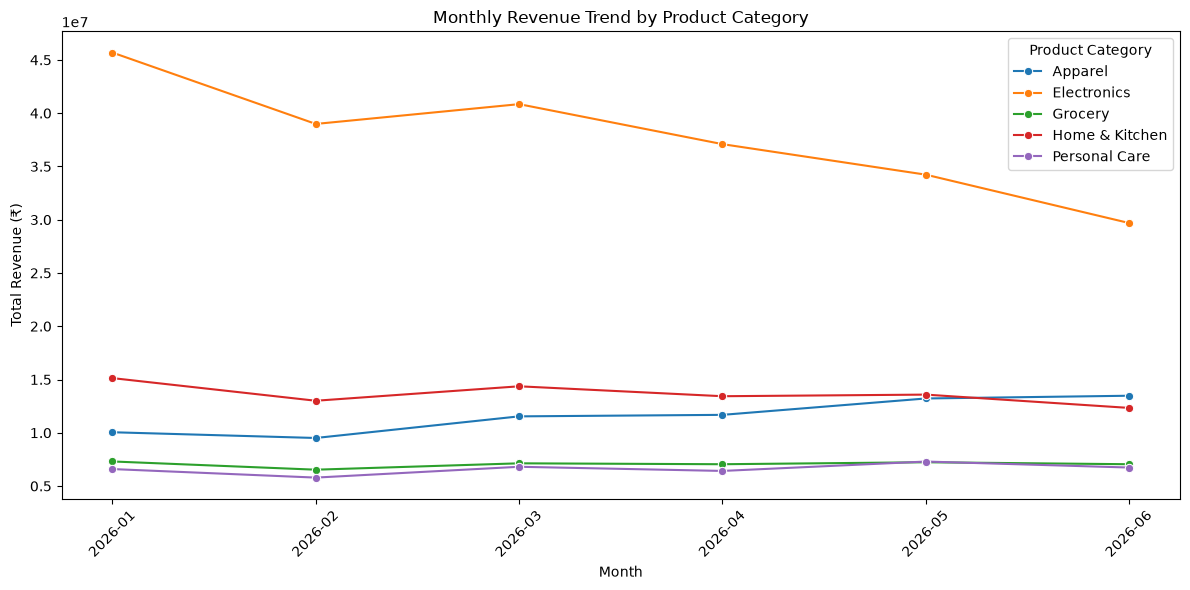

In [20]:
# Plot monthly revenue trends for each product category
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_category_revenue,
    x='month',
    y='revenue',
    hue='category',
    marker='o'
)

plt.title('Monthly Revenue Trend by Product Category')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.tight_layout()

plt.show()

In [21]:
# Reshape revenue data so each category becomes a column
category_change = (
    monthly_category_revenue
    .pivot(index='month', columns='category', values='revenue')
)

category_change

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


In [22]:
# Calculate the percentage revenue change from the first month to the last month
percentage_change = (
    (category_change.iloc[-1] - category_change.iloc[0])
    / category_change.iloc[0]
) * 100

percentage_change.sort_values()

category
Electronics      -35.020713
Home & Kitchen   -18.489275
Grocery           -3.548538
Personal Care      2.178118
Apparel           34.100144
dtype: float64

In [23]:
# Calculate the coefficient of variation to measure revenue consistency
consistency = (
    category_change.std() / category_change.mean()
) * 100

consistency.sort_values()

category
Grocery            3.866514
Home & Kitchen     7.257251
Personal Care      7.520799
Apparel           13.881951
Electronics       14.602453
dtype: float64

In [24]:
# Recreate the category-by-month revenue comparison table
category_change = (
    monthly_category_revenue
    .pivot(index='month', columns='category', values='revenue')
)

category_change

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


In [25]:
# Recalculate percentage revenue change for each category
percentage_change = (
    (category_change.iloc[-1] - category_change.iloc[0])
    / category_change.iloc[0]
) * 100

percentage_change.sort_values()

category
Electronics      -35.020713
Home & Kitchen   -18.489275
Grocery           -3.548538
Personal Care      2.178118
Apparel           34.100144
dtype: float64

In [26]:
# Recalculate revenue consistency using the coefficient of variation
consistency = (
    category_change.std() / category_change.mean()
) * 100

consistency.sort_values()

category
Grocery            3.866514
Home & Kitchen     7.257251
Personal Care      7.520799
Apparel           13.881951
Electronics       14.602453
dtype: float64

Step 5.2 — Category Revenue Trend

Business Interpretation:
The monthly revenue trends show clear differences across the five categories. Electronics has experienced the steepest decline, falling from ₹4.57 crore in January to ₹2.97 crore in June, representing a 35.02% decrease. This declining trend is a warning signal for the Category Manager, and the Electronics supplier should be challenged to explain the decline before additional shelf space or promotional investment is committed.

Grocery is the most consistent category, with a coefficient of variation of only 3.87% across the six months. Its monthly revenue remained relatively stable, ranging from approximately ₹65 lakh to ₹73 lakh, making it a predictable contributor to overall revenue and a strong category for maintaining stable shelf presence.

Apparel also shows a strong positive trend, increasing by 34.10% from January to June, suggesting growing customer demand and a potential case for increased attention or investment.

Member 1 findings:
📉 Electronics declined by 35.02% from January to June and is the steepest declining category.
📈 Apparel increased by 34.10%, showing the strongest growth.
📊 Grocery is the most consistent category with a 3.87% coefficient of variation.

# Step 5.3 — Top and Bottom Products by Category

In this step, we identify the **top 2 and bottom 2 products by total revenue within each product category** over the six-month period.

The purpose is to understand which products are driving category performance and which products may need attention during the supplier review.

In [27]:
# Group the transactions by category and product.
# Summing revenue gives the total six-month revenue generated by each product.
product_revenue = (
    df.groupby(['category', 'product_name'])['revenue']
      .sum()
      .reset_index()
)

# Rename the revenue column to make the table easier to understand.
product_revenue = product_revenue.rename(
    columns={'revenue': 'total_revenue'}
)

# Display the product-level revenue table.
display(product_revenue.head(10))

,category,product_name,total_revenue
0,Apparel,Formal Shirt,13748976.91
1,Apparel,Jeans,13862749.46
2,Apparel,Kurta,13606747.03
3,Apparel,Saree,14161864.63
4,Apparel,T-Shirt,14099251.65
5,Electronics,Headphones,47696053.99
6,Electronics,Laptop,46551078.39
7,Electronics,Mobile Phone,45654037.41
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93


In [28]:
# Sort products from highest to lowest revenue within each category.
# This lets us select the strongest products first.
product_revenue_desc = product_revenue.sort_values(
    ['category', 'total_revenue'],
    ascending=[True, False]
)

# Select the top 2 products from every category.
top_2_products = (
    product_revenue_desc
    .groupby('category', group_keys=False)
    .head(2)
)

# Display the top-performing products.
display(top_2_products)

,category,product_name,total_revenue
3,Apparel,Saree,14161864.63
4,Apparel,T-Shirt,14099251.65
5,Electronics,Headphones,47696053.99
6,Electronics,Laptop,46551078.39
13,Grocery,Rice (5kg),8562171.86
11,Grocery,Dal (1kg),8488303.64
16,Home & Kitchen,Mixer Grinder,16903254.58
18,Home & Kitchen,Storage Box,16676535.31
22,Personal Care,Shampoo,8168328.26
20,Personal Care,Body Lotion,8106578.00


In [29]:
# Sort products from lowest to highest revenue within each category.
# This lets us identify the products that generated the least revenue.
product_revenue_asc = product_revenue.sort_values(
    ['category', 'total_revenue'],
    ascending=[True, True]
)

# Select the bottom 2 products from every category.
bottom_2_products = (
    product_revenue_asc
    .groupby('category', group_keys=False)
    .head(2)
)

# Display the bottom-performing products.
display(bottom_2_products)

,category,product_name,total_revenue
2,Apparel,Kurta,13606747.03
0,Apparel,Formal Shirt,13748976.91
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93
14,Grocery,Sugar (1kg),8377786.05
12,Grocery,Oil (1L),8431630.01
19,Home & Kitchen,Water Bottle,15825842.17
17,Home & Kitchen,Pressure Cooker,16142329.39
23,Personal Care,Sunscreen,7593863.45
24,Personal Care,Toothpaste,7768812.48


In [30]:
# Add a label to distinguish the top and bottom products.
top_table = top_2_products.copy()
top_table['performance'] = 'Top 2'

bottom_table = bottom_2_products.copy()
bottom_table['performance'] = 'Bottom 2'

# Combine both results into one summary table.
product_summary = pd.concat(
    [top_table, bottom_table],
    ignore_index=True
)

# Sort the final table so each category is shown together.
product_summary = product_summary.sort_values(
    ['category', 'performance', 'total_revenue'],
    ascending=[True, True, False]
)

# Display the complete summary table.
display(product_summary)

,category,product_name,total_revenue,performance
11,Apparel,Formal Shirt,13748976.91,Bottom 2
10,Apparel,Kurta,13606747.03,Bottom 2
0,Apparel,Saree,14161864.63,Top 2
1,Apparel,T-Shirt,14099251.65,Top 2
13,Electronics,Tablet,44744388.93,Bottom 2
12,Electronics,Smart TV,41882166.21,Bottom 2
2,Electronics,Headphones,47696053.99,Top 2
3,Electronics,Laptop,46551078.39,Top 2
15,Grocery,Oil (1L),8431630.01,Bottom 2
14,Grocery,Sugar (1kg),8377786.05,Bottom 2


### Step 5.3 — Business Interpretation

The product-level analysis shows that **Electronics is the largest revenue-generating category**, but it also needs the closest review because the category has already shown the steepest decline in Step 5.2.

Within Electronics, **Headphones (₹47.70 million)** and **Laptop (₹46.55 million)** are the strongest products. In contrast, **Smart TV (₹41.88 million)** and **Tablet (₹44.74 million)** are the lowest two products in the category.

For the supplier review, **Electronics should be the category to challenge**. It contributes the highest total revenue, but its declining category trend means the supplier needs to explain how it will protect and improve performance. The weaker products, particularly Smart TV, should receive additional attention before further promotional or shelf-space investment is approved.

# Step 5.4 — Discount Effectiveness Analysis

The assignment asks us to compare transactions at **0%, 5%, 10%, 15%, 20%, and 25%+ discount levels**.

We will calculate:
- Average revenue per transaction
- Average units sold per transaction
- Number of transactions in each discount bracket

Then we will use a bar chart and the numbers to decide whether higher discounts are producing a meaningful return.

In [32]:
# Create the required discount brackets.
# The dataset contains discount percentages from 0% to 20%.
# The 25%+ bracket is still included because it is required by the assignment.
def create_discount_bracket(discount):
    if discount == 0:
        return '0%'
    elif discount == 5:
        return '5%'
    elif discount == 10:
        return '10%'
    elif discount == 15:
        return '15%'
    elif discount == 20:
        return '20%'
    else:
        return '25%+'

df['discount_bracket'] = df['discount_pct'].apply(create_discount_bracket)

# Check the number of transactions in each bracket.
discount_counts = (
    df['discount_bracket']
    .value_counts()
    .reindex(['0%', '5%', '10%', '15%', '20%', '25%+'], fill_value=0)
)

display(discount_counts.to_frame('transaction_count'))

,transaction_count
discount_bracket,
0%,36033
5%,23922
10%,23810
15%,11935
20%,12136
25%+,0


In [33]:
# Calculate the average revenue and average units sold for each discount bracket.
discount_analysis = (
    df.groupby('discount_bracket')
      .agg(
          average_revenue=('revenue', 'mean'),
          average_units_sold=('units_sold', 'mean'),
          transaction_count=('transaction_id', 'count')
      )
      .reindex(['0%', '5%', '10%', '15%', '20%', '25%+'])
)

# Display the discount effectiveness table.
display(discount_analysis)

,average_revenue,average_units_sold,transaction_count
discount_bracket,,,
0%,4685.654340,2.586018,36033.0
5%,4303.730312,2.591882,23922.0
10%,4005.545405,2.566401,23810.0
15%,4069.164408,2.595140,11935.0
20%,3631.727433,2.581493,12136.0
25%+,NaN,NaN,NaN


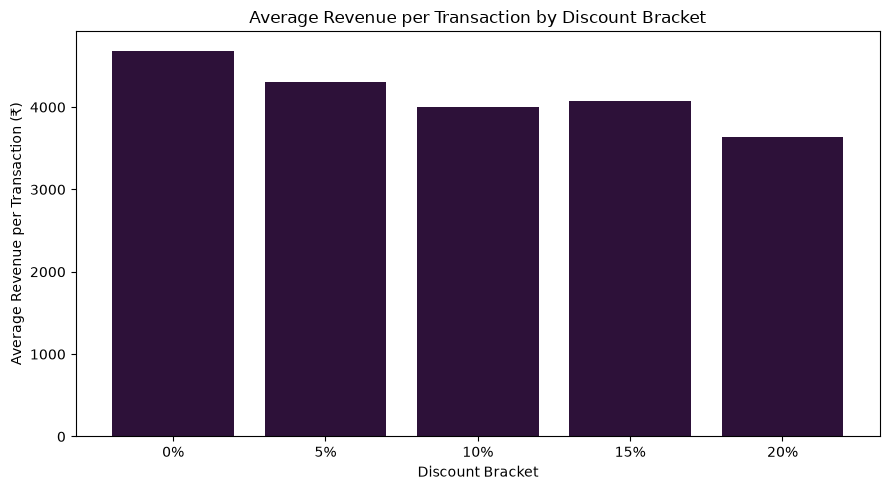

In [67]:
# Remove discount brackets with no transactions before plotting.
# The dataset has no 25%+ discount transactions, so its average revenue is NaN.
discount_plot = (
    discount_analysis
    .dropna(subset=['average_revenue'])
    .reset_index()
)

# Plot average revenue for each available discount bracket.
plt.figure(figsize=(9, 5))

plt.bar(
    discount_plot['discount_bracket'],
    discount_plot['average_revenue'],
         # Deep Plum
       
   color="#2D1139"  
)


plt.title('Average Revenue per Transaction by Discount Bracket')
plt.xlabel('Discount Bracket')
plt.ylabel('Average Revenue per Transaction (₹)')

plt.tight_layout()
plt.show()

### Step 5.4 — Business Interpretation

The discount analysis gives a clear signal: **higher discounts are not generating higher revenue per transaction**.

Average revenue per transaction falls from **₹4,685.65 at 0% discount** to **₹4,303.73 at 5%**, **₹4,005.55 at 10%**, and **₹3,631.73 at 20%**. Average units sold remain almost unchanged, ranging from about **2.57 to 2.60 units** across the available discount levels.

Therefore, the current discount pattern does not show a proportionate increase in units sold or revenue per transaction. The Category Manager should challenge suppliers to justify deeper discounts with evidence of incremental volume, rather than assuming that a larger discount automatically improves performance.

**Note:** There are no transactions in the dataset with a discount of 25% or more, so the 25%+ bracket has no calculated average.

# Step 5.5 — Day-of-Week and Monthly Sales Patterns

This step looks at when customers naturally generate more or less revenue.

First, we will calculate **average transaction revenue by day of week** for the whole retail chain. Then we will calculate **total revenue by month**.

Because Step 5.2 identified **Electronics as the most interesting category due to its steep decline**, we will repeat the day-of-week and monthly analysis for Electronics and compare its pattern with the overall chain.

In [68]:
# Convert the date column to datetime format.
# This allows us to extract the day of week from each transaction date.
df['date'] = pd.to_datetime(df['date'])

# Extract the day name for every transaction.
df['day_of_week'] = df['date'].dt.day_name()

# Define the natural Monday-to-Sunday order for the chart.
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Calculate average transaction revenue for each day.
daily_revenue = (
    df.groupby('day_of_week')['revenue']
      .mean()
      .reindex(day_order)
)

# Display the result.
display(daily_revenue.to_frame('average_revenue_per_transaction'))

,average_revenue_per_transaction
day_of_week,
Monday,4131.380009
Tuesday,4017.706483
Wednesday,4289.790612
Thursday,4255.307474
Friday,4255.921458
Saturday,4420.019374
Sunday,4352.211678


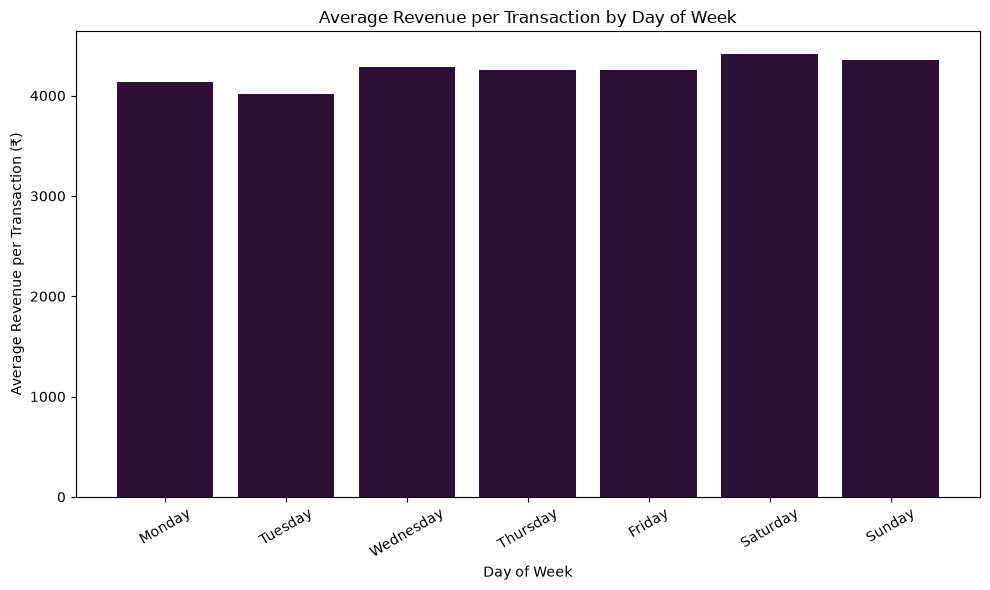

In [69]:
# Plot average transaction revenue by day of week. 
plt.figure(figsize=(10, 6)) 
 
plt.bar( 
    daily_revenue.index, 
    daily_revenue.values,
   
    color="#2D1139"
) 
 
plt.title('Average Revenue per Transaction by Day of Week') 
plt.xlabel('Day of Week') 
plt.ylabel('Average Revenue per Transaction (₹)') 
plt.xticks(rotation=30) 
plt.tight_layout() 
 
plt.show()

In [70]:
# Identify the best and worst day for the overall chain.
best_day = daily_revenue.idxmax()
best_day_value = daily_revenue.max()

worst_day = daily_revenue.idxmin()
worst_day_value = daily_revenue.min()

# Display the best and worst days.
print(f"Best day: {best_day} — ₹{best_day_value:,.2f} average revenue per transaction")
print(f"Worst day: {worst_day} — ₹{worst_day_value:,.2f} average revenue per transaction")

Best day: Saturday — ₹4,420.02 average revenue per transaction
Worst day: Tuesday — ₹4,017.71 average revenue per transaction


In [71]:
# Create a month column from the transaction date.
df['month'] = df['date'].dt.to_period('M')

# Calculate total revenue for each month.
monthly_revenue = (
    df.groupby('month')['revenue']
      .sum()
)

# Display monthly total revenue.
display(monthly_revenue.to_frame('total_revenue'))

,total_revenue
month,
2026-01,84768131.10
2026-02,73833666.23
2026-03,80689884.84
2026-04,75670487.12
2026-05,75559873.38
2026-06,69282134.11


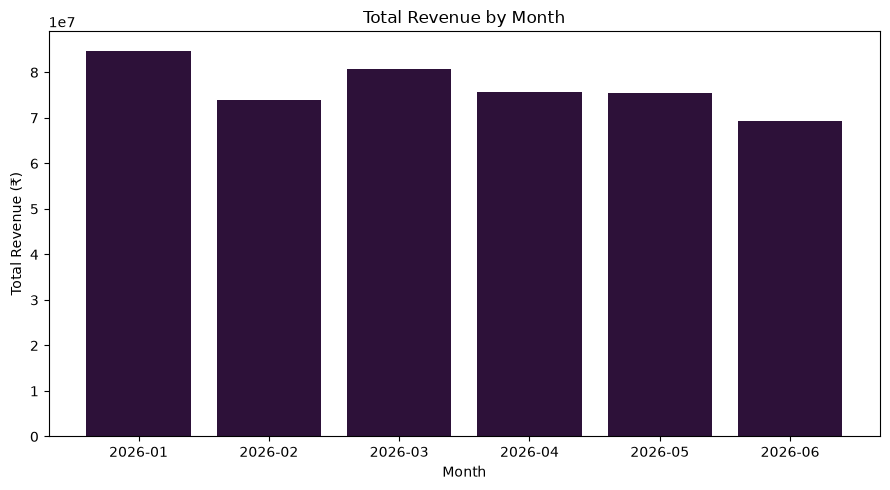

In [79]:
# Plot total revenue by month.
plt.figure(figsize=(9, 5))

plt.bar(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    color="#2D1139"
)

plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()

plt.show()

In [73]:
# Identify the best and worst month for the overall chain.
best_month = monthly_revenue.idxmax()
best_month_value = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_month_value = monthly_revenue.min()

# Display the best and worst months.
print(f"Best month: {best_month} — ₹{best_month_value:,.2f}")
print(f"Worst month: {worst_month} — ₹{worst_month_value:,.2f}")

Best month: 2026-01 — ₹84,768,131.10
Worst month: 2026-06 — ₹69,282,134.11


In [74]:
# Filter the dataset to the most interesting category identified in Step 5.2.
# Electronics was selected because it had the steepest decline.
interesting_category = 'Electronics'
category_df = df[df['category'] == interesting_category].copy()

# Calculate average transaction revenue by day for Electronics.
category_daily_revenue = (
    category_df.groupby('day_of_week')['revenue']
               .mean()
               .reindex(day_order)
)

# Display Electronics day-of-week performance.
display(
    category_daily_revenue.to_frame(
        'average_revenue_per_transaction'
    )
)

,average_revenue_per_transaction
day_of_week,
Monday,56603.954238
Tuesday,54306.748373
Wednesday,59126.560234
Thursday,55088.747545
Friday,56798.062589
Saturday,56858.163770
Sunday,56032.350249


In [75]:
# Calculate monthly total revenue for Electronics.
category_monthly_revenue = (
    category_df.groupby('month')['revenue']
               .sum()
)

# Display Electronics monthly revenue.
display(category_monthly_revenue.to_frame('total_revenue'))

,total_revenue
month,
2026-01,45686596.63
2026-02,38988602.50
2026-03,40846509.47
2026-04,37092265.09
2026-05,34226926.43
2026-06,29686824.81


In [76]:
# Identify the best and worst day for Electronics.
category_best_day = category_daily_revenue.idxmax()
category_best_day_value = category_daily_revenue.max()

category_worst_day = category_daily_revenue.idxmin()
category_worst_day_value = category_daily_revenue.min()

# Identify the best and worst month for Electronics.
category_best_month = category_monthly_revenue.idxmax()
category_best_month_value = category_monthly_revenue.max()

category_worst_month = category_monthly_revenue.idxmin()
category_worst_month_value = category_monthly_revenue.min()

# Display the results.
print(
    f"Electronics best day: {category_best_day} — "
    f"₹{category_best_day_value:,.2f} average revenue per transaction"
)
print(
    f"Electronics worst day: {category_worst_day} — "
    f"₹{category_worst_day_value:,.2f} average revenue per transaction"
)
print(
    f"Electronics best month: {category_best_month} — "
    f"₹{category_best_month_value:,.2f}"
)
print(
    f"Electronics worst month: {category_worst_month} — "
    f"₹{category_worst_month_value:,.2f}"
)

Electronics best day: Wednesday — ₹59,126.56 average revenue per transaction
Electronics worst day: Tuesday — ₹54,306.75 average revenue per transaction
Electronics best month: 2026-01 — ₹45,686,596.63
Electronics worst month: 2026-06 — ₹29,686,824.81


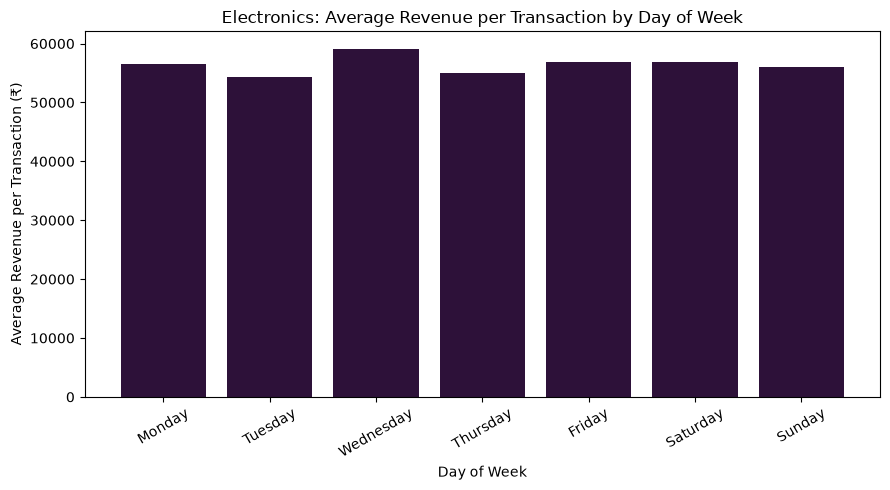

In [80]:
# Plot Electronics average transaction revenue by day of week.
plt.figure(figsize=(9, 5))

plt.bar(
    category_daily_revenue.index,
    category_daily_revenue.values,
    color="#2D1139"
)

plt.title('Electronics: Average Revenue per Transaction by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue per Transaction (₹)')
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

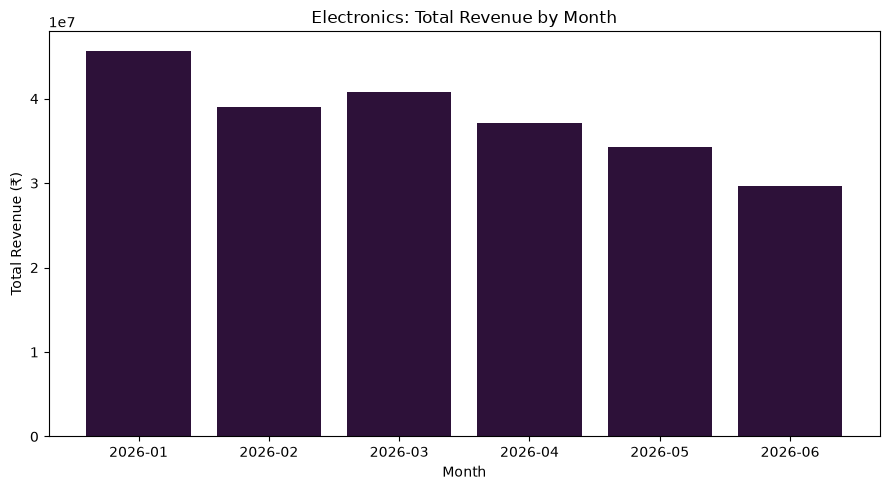

In [81]:
# Plot Electronics total revenue by month.
plt.figure(figsize=(9, 5))

plt.bar(
    category_monthly_revenue.index.astype(str),
    category_monthly_revenue.values,
    color="#2D1139"
)

plt.title('Electronics: Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()

plt.show()

### Step 5.5 — Business Interpretation

For the overall chain, **Saturday is the strongest day**, with average revenue of about **₹4,420.02 per transaction**, while **Tuesday is the weakest**, at about **₹4,017.71**. The strongest month is **January (₹84.77 million)** and the weakest is **June (₹69.28 million)**.

Electronics follows a similar monthly pattern to the overall chain: **January is its strongest month at ₹45.69 million and June is its weakest at ₹29.69 million**. However, Electronics shows a different day-of-week pattern: **Wednesday is its strongest day (about ₹59,126.56 per transaction)** and **Tuesday is its weakest (about ₹54,306.75)**.

For promotional timing, the chain can consider stronger broad promotions around the weekend, especially Saturday, while Electronics-specific promotions may be better tested on Wednesday rather than assuming the overall chain pattern applies to every category. The persistent month-on-month decline in Electronics is more important than the day effect, so promotions should be targeted and measured for incremental revenue rather than simply increasing discount levels.